# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [5]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [7]:
import pandas as pd

df = pd.read_csv('/content/drebin-215-dataset-5560malware-9476-benign.csv')
print(df.shape)
print(df.head())

(15036, 216)
   transact  onServiceConnected  bindService  attachInterface  \
0         0                   0            0                0   
1         0                   0            0                0   
2         0                   0            0                0   
3         0                   0            0                0   
4         0                   0            0                0   

   ServiceConnection  android.os.Binder  SEND_SMS  \
0                  0                  0         1   
1                  0                  0         1   
2                  0                  0         1   
3                  0                  0         0   
4                  0                  0         0   

   Ljava.lang.Class.getCanonicalName  Ljava.lang.Class.getMethods  \
0                                  0                            0   
1                                  0                            0   
2                                  0                            0   
3

/tmp/ipykernel_22147/2140615450.py:3: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drebin-215-dataset-5560malware-9476-benign.csv')


In [10]:
# sample 5000 rows to make training faster

# Sample 5000 rows from the DataFrame
df = df.sample(n=5000, random_state=42)

# Now df_sampled contains your sampled data
df.shape


(5000, 216)

## Data Preprocessing & Feature Engineering

In [15]:

# Replace '?' with NaN and drop missing values
df = df.replace('?', pd.NA)
df = df.dropna()

# Encode any remaining non-numeric columns
for col in df.columns:
    if df[col].dtype == 'object' and col != 'class':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# Check label column
print(df['class'].value_counts())

# Encode label
encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])



class
0    3144
1    1853
Name: count, dtype: int64


## Splitting Data into Training and Testing Sets

In [18]:
# Features and label
X = df.drop('class', axis=1)
y = df['class']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (3997, 215)
Testing set size: (1000, 215)


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [19]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# SVM
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Random Forest Accuracy: 0.983
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       629
           1       0.99      0.96      0.98       371

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Gradient Boosting Accuracy: 0.973
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       629
           1       0.98      0.94      0.96       371

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

SVM Accuracy: 0.976
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       629
           1       0.98      0.96      0.97       371

    accuracy                           0.98      1000
   macro avg       0.98      0.97      0.97 

## Building a Neural Network Classifier

In [20]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7828 - loss: 0.4675 - val_accuracy: 0.9450 - val_loss: 0.2029
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9174 - loss: 0.2270 - val_accuracy: 0.9580 - val_loss: 0.1330
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9477 - loss: 0.1538 - val_accuracy: 0.9670 - val_loss: 0.1074
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9520 - loss: 0.1302 - val_accuracy: 0.9700 - val_loss: 0.1023
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9650 - loss: 0.1074 - val_accuracy: 0.9710 - val_loss: 0.0994
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9705 - loss: 0.0887 - val_accuracy: 0.9730 - val_loss: 0.0951
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9715 - loss: 0.0826 - val_accuracy: 0.9750 - val_loss: 0.1050
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9780 - loss: 0.0710 - val_accuracy: 0

## Evaluating Neural Network Performance

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network Accuracy: 0.984
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       629
           1       0.99      0.97      0.98       371

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



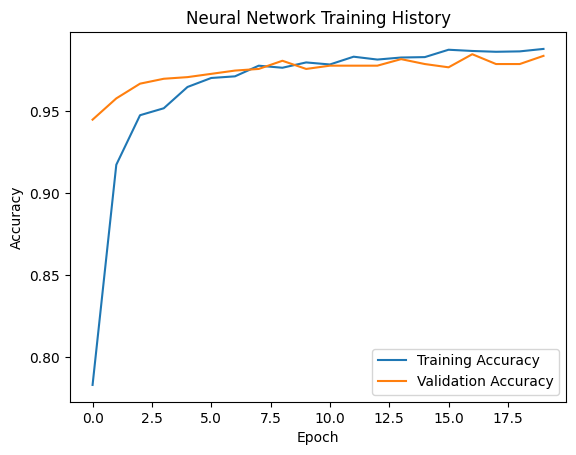

In [21]:

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


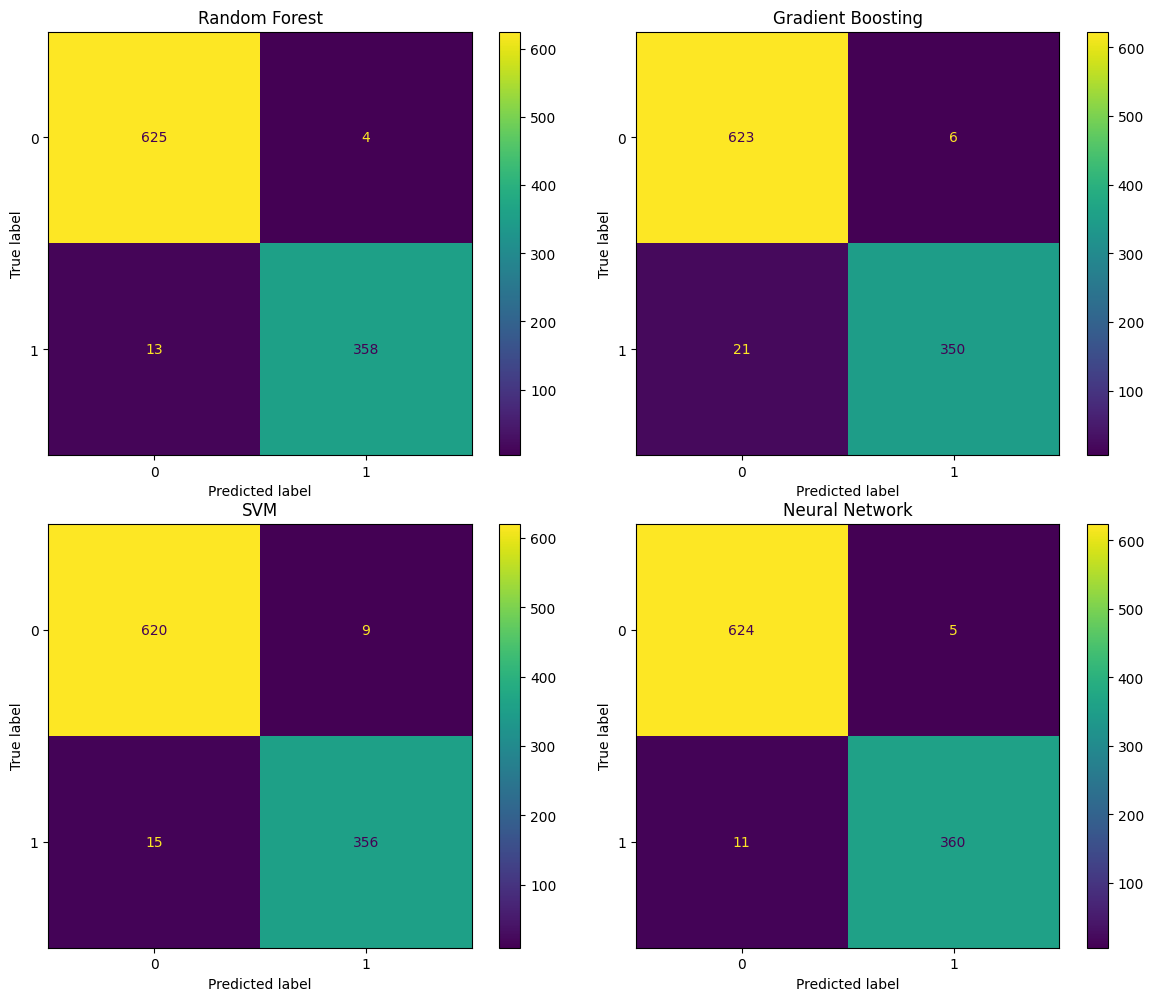

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = [('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb),
                ('SVM', y_pred_svm), ('Neural Network', y_pred_nn)]

for ax, (name, preds) in zip(axes.flatten(), models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Among the four models, Random Forest and Neural Network achieved the highest accuracy ~98%. Random Forest performs best due to its ensemble approach which reduces overfitting. Neural Network closely follows, benefiting from its ability to learn complex patterns. Gradient Boosting and SVM also performed well but had slightly more misclassifications.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ['Random Forest', 'Gradient Boosting','SVM', 'Neural Network']

accuracies = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_nn)
]

precisions = [
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_gb),
    precision_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_nn)
]

recalls = [
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_gb),
    recall_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_nn)
]

f1_scores = [
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_gb),
    f1_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_nn)
]

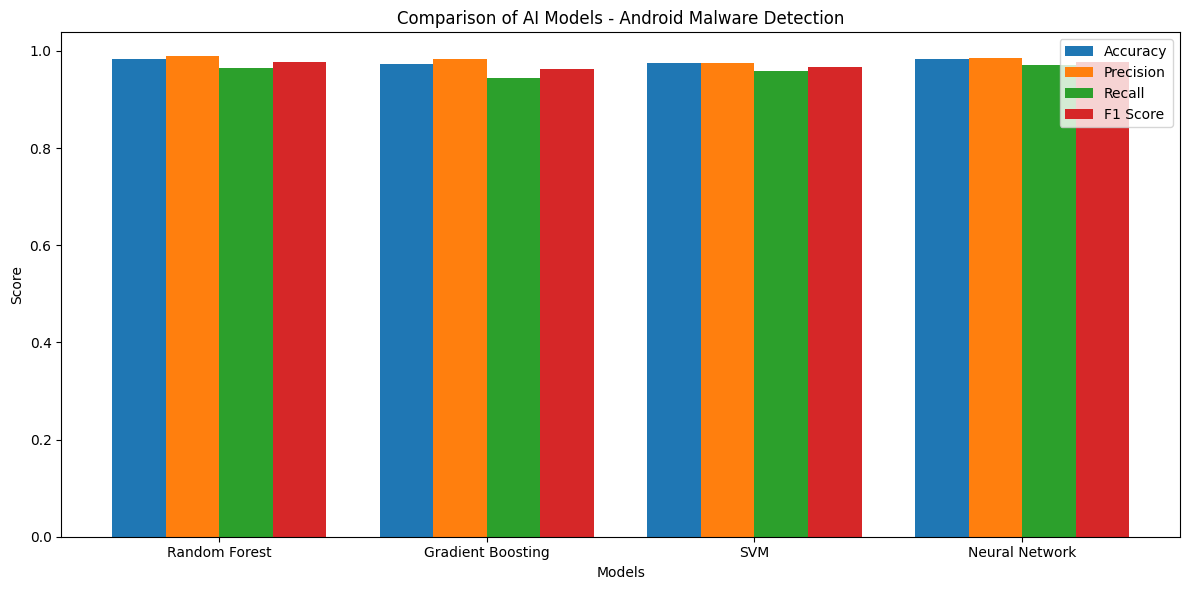

In [23]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracies, width, label='Accuracy')
ax.bar(x - 0.5*width, precisions, width, label='Precision')
ax.bar(x + 0.5*width, recalls, width, label='Recall')
ax.bar(x + 1.5*width, f1_scores, width, label='F1 Score')

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Comparison of AI Models - Android Malware Detection')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.tight_layout()
plt.show()

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.